In [1]:
import xarray as xr
import numpy as np
from scipy.signal import convolve2d
from matplotlib.axes import Axes
import matplotlib.pyplot as plt



def smooth_phasor(phasor,count,size: int = 3):
      kernel = np.ones((size, size), dtype=np.float32)

      # Set invalid phasors to 0
      valid = np.isfinite(phasor) & (count > 0)
      phasor_weighted = np.zeros_like(phasor, dtype=np.complex64)
      phasor_weighted[valid] = phasor[valid] * count[valid]
      count_weighted = np.zeros_like(count, dtype=np.float32)
      count_weighted[valid] = count[valid]

      # Convolve
      num = convolve2d(phasor_weighted.real, kernel, mode='same') + \
            1j * convolve2d(phasor_weighted.imag, kernel, mode='same')
      den = convolve2d(count_weighted, kernel, mode='same')

      # Normalize
      phasor_smoothed = np.full_like(phasor, np.nan + 1j * np.nan)
      mask = den > 0
      phasor_smoothed[mask] = num[mask] / den[mask]

      return phasor_smoothed


def get_phasor_from_decay(
    decay: np.ndarray,
    tcspc_resolution: float,
    sync_rate: float,
) -> complex:
    """
    Photon‑weighted complex phasor from a TCSPC decay.

    Parameters
    ----------
    decay : 1‑D np.ndarray
        Photon counts per TCSPC channel.
    tcspc_resolution_ns : float
        Width of one TCSPC channel in seconds.
    sync_rate : float
        Laser repetition rate in Hz.

    Returns
    -------
    complex
        Phasor Φ = g + i·s.
        Returns nan+1j*nan if the decay is empty.
    """
    if decay.ndim != 1:
        raise ValueError("`decay` must be 1‑D")

    total = decay.sum()
    if total == 0:
        return np.nan + 1j * np.nan

    # Time axis (ns)
    t = np.arange(decay.size) * tcspc_resolution

    # Angular modulation frequency (rad/ns)
    omega = 2 * np.pi * sync_rate  # Hz → ns⁻¹

    # Complex numerator and normalization
    phasor = np.dot(decay, np.exp(1j * omega * t)) / total
    return phasor


def draw_unitary_circle(ax: Axes, sync_rate, tau_max: int = None, tick_length=0.02):
    if not isinstance(ax, Axes):
        raise TypeError(f"'ax' must be a matplotlib Axes object, got {type(ax).__name__}")
    
    omega = 2 * np.pi * sync_rate

    if tau_max is None:
        period_ns = 1e9 / sync_rate
        tau_max = int(np.ceil(period_ns / 2))
        
    taus_ns = np.arange(1, tau_max + 1)
    

    center = np.array([0.5, 0])
    radius = 0.5

    # Generate circle points
    theta = np.linspace(0, np.pi, 300)
    g_circle = center[0] + radius * np.cos(theta)
    s_circle = center[1] + radius * np.sin(theta)
    ax.plot(g_circle, s_circle, 'w-', label='Universal Circle',lw = 1)

    # Phasor function
    def phasor(tau):
        g = 1 / (1 + (omega * tau)**2)
        s = (omega * tau) / (1 + (omega * tau)**2)
        return np.array([g, s])

    # Draw ticks
    for tau_ns in taus_ns:
        tau_s = tau_ns * 1e-9
        p = phasor(tau_s)
        v = p - center
        v_unit = v / np.linalg.norm(v)
        p1 = p - (tick_length / 2) * v_unit
        p2 = p + (tick_length / 2) * v_unit
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'w-', lw=1)
        label_pos = p + (tick_length * 1.2) * v_unit
        ax.text(label_pos[0], label_pos[1], f'{tau_ns} ns', fontsize=8,
                ha='center', va='center' , color = 'w')

    # Clean formatting
    ax.set_aspect('equal')
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('g')
    ax.set_ylabel('s')


def average_phasor(
    phasor: np.ndarray,
    photon_count: np.ndarray,
    mask: np.ndarray | None = None,
) -> complex:
    """
    Photon‑weighted mean phasor over a region of interest.

    Parameters
    ----------
    phasor : np.ndarray
        Complex array (g + i·s) for each pixel.
    photon_count : np.ndarray
        Photon counts per pixel (same shape as `phasor`).
    mask : np.ndarray or None, optional
        Boolean / int array with the same shape.
        *True* (or non‑zero) selects pixels to include.
        If None, all pixels are eligible.

    Returns
    -------
    complex
        Weighted average phasor.
        Returns nan+1j*nan if the ROI has zero total photons.
    """
    if phasor.shape != photon_count.shape:
        raise ValueError("phasor and photon_count must have identical shapes")
    if mask is not None and mask.shape != phasor.shape:
        raise ValueError("mask must have the same shape as phasor")

    # Build a validity mask:  count>0  &  phasor finite  &  (ROI mask if given)
    valid = (photon_count > 0) & np.isfinite(phasor)
    if mask is not None:
        valid &= mask.astype(bool)

    if not np.any(valid):
        return np.nan + 1j * np.nan

    # Photon‑weighted sum and total photon count
    weighted_sum = np.sum(phasor[valid] * photon_count[valid])
    total_photons = np.sum(photon_count[valid])

    if total_photons == 0:
        return np.nan + 1j * np.nan

    return weighted_sum / total_photons

def shift_decay(arr, n):
    wrapped = np.roll(arr, -n) 
    return wrapped


Load data

In [2]:
# Constants read from the header:
MeasDesc_Resolution = 5e-12
TTResult_SyncRate = 39999890 

# result = xr.open_dataset("MultiHarp150_2025-06-18_16-37-45.274_f4_ch1_accu1__ch2_accu3_px500.h5")
# result = xr.open_dataset("MultiHarp150_2025-06-18_16-32-30.231_f3_ch1_accu1_px500.h5")
result = xr.open_dataset('data/MultiHarp150_2025-07-09_17-16-49.326_500px_1accu_STAR488.h5')
# result = xr.open_dataset('data/LSM_512x_modi_f1_accu1.h5')

count = np.array(result.photon_count.transpose("frame","sequence","channel","line","pixel"), dtype=int)
lifetime = np.array(result.mean_photon_arrival_time.transpose("frame","sequence","channel","line","pixel"), dtype=float) * MeasDesc_Resolution * 1e9
g = np.array(result.phasor_g.transpose("frame","sequence","channel","line","pixel"), dtype=float)
s = np.array(result.phasor_s.transpose("frame","sequence","channel","line","pixel"), dtype=float)

# get intensity
count = count[0,0,0,:,:]

# slice phasor coordinates
g = g[0,0,0,:,:]
s = s[0,0,0,:,:]

phasor = g + 1j * s

decay = result.tcspc_histogram


Smooth and show pixel phasors

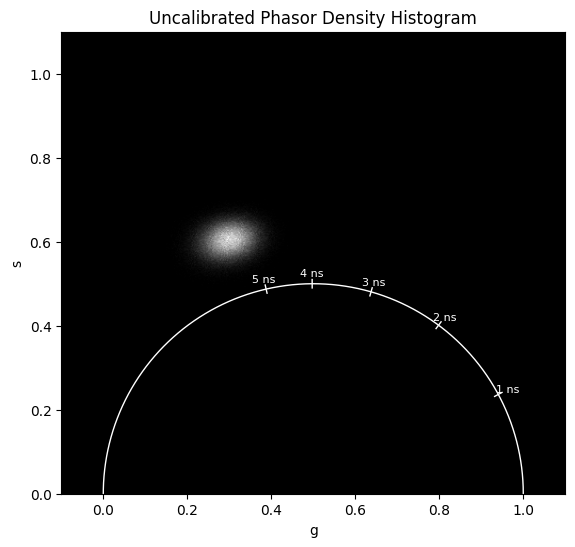

In [3]:
phasor_smoothed = smooth_phasor(phasor, count)

valid = valid = np.isfinite(phasor) & (count > 0)


g_smooth = phasor_smoothed[valid].real
s_smooth = phasor_smoothed[valid].imag

H, xedges, yedges = np.histogram2d(g_smooth, s_smooth, bins=150)


fig, ax = plt.subplots(figsize=(8,6))
# ax.imshow(np.power(H.T,2), origin='lower',
#           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
#           cmap='gray', aspect='equal')
ax.imshow(H.T, origin='lower',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          cmap='gray', aspect='equal')
ax.set_xlabel('g')
ax.set_ylabel('s')
ax.set_title('Uncalibrated Phasor Density Histogram')
ax.set_xlim((0,1))
ax.set_ylim((0,1))
ax.set_facecolor('black')


draw_unitary_circle(ax, sync_rate=TTResult_SyncRate, tau_max = 5)

# ax.plot(phasor_measured.real,phasor_measured.imag,"rs")
plt.show()



Calibrate phasor

In [4]:
tau = 3.834e-9 # recorded lifetime of STAR 488 in water

phasor_theory = 1 / (1 - 1j * 2 * np.pi * TTResult_SyncRate * tau)

print(phasor_theory)

(0.5185379307065864+0.4996562269452046j)


Average phasor calcuated from all pixels:  (0.29777028421187407+0.6021875698878555j)
Phasor calculated from the TCSPC histogram (0.29777028379167375+0.602187566044494j)


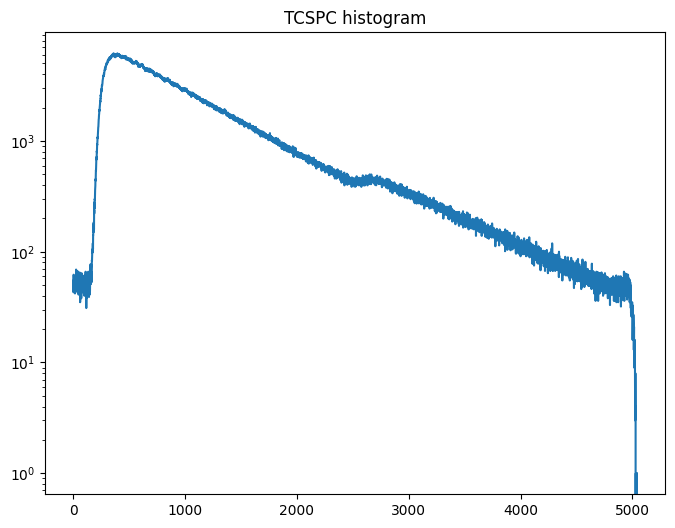

In [5]:
# Option 1: Calculate phasor from TCSPC histogram by numerical integration
# Option 2: Calculate phasor by weight-averaging phasor from all pixels

mask = np.ones_like(count) 
phasor_from_image = average_phasor(phasor,count,mask=None) # will give the same result as with mask=None
print("Average phasor calcuated from all pixels: ", phasor_from_image)

phasor_from_decay = get_phasor_from_decay(decay=decay.data, tcspc_resolution=MeasDesc_Resolution,sync_rate=TTResult_SyncRate)
print("Phasor calculated from the TCSPC histogram", phasor_from_decay)



fig, ax = plt.subplots(figsize = (8,6))
ax.semilogy(decay["tcspc_channel"].data,decay.data)
ax.set_title("TCSPC histogram")
plt.show()

(1.0088521467678606-0.36223222291435364j)


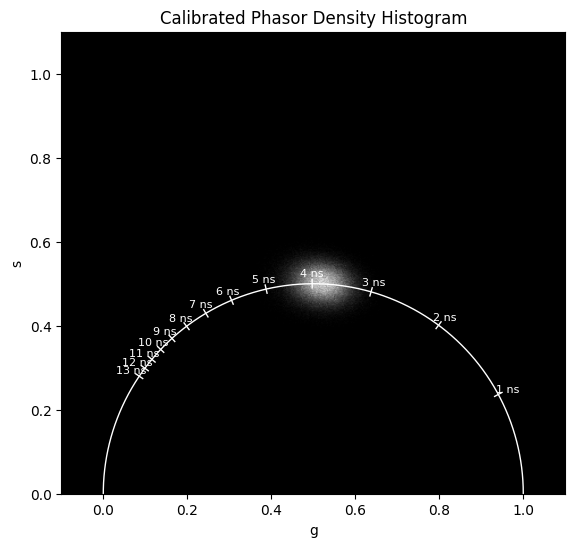

In [6]:
# obtained from phasor averaging:
# calibration_factor = 1.00885214-0.36223222j
calibration_factor = phasor_theory / phasor_from_decay
print(calibration_factor)

phasor_calibrated = phasor * calibration_factor
phasor_calibrated_smoothed = smooth_phasor(phasor_calibrated,count)

valid = valid = np.isfinite(phasor) & (count > 0)


g_calibrated_smooth = phasor_calibrated_smoothed[valid].real
s_calibrated_smooth = phasor_calibrated_smoothed[valid].imag

H, xedges, yedges = np.histogram2d(g_calibrated_smooth, s_calibrated_smooth, bins=150)

fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(H.T, origin='lower',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          cmap='gray', aspect='equal')
ax.set_xlabel('g')
ax.set_ylabel('s')
ax.set_title('Calibrated Phasor Density Histogram')
ax.set_xlim((0,1))
ax.set_ylim((0,1))
ax.set_facecolor('black')

draw_unitary_circle(ax=ax,sync_rate=TTResult_SyncRate)
plt.show()


Hack: making the lowest 2D histogram value transparent

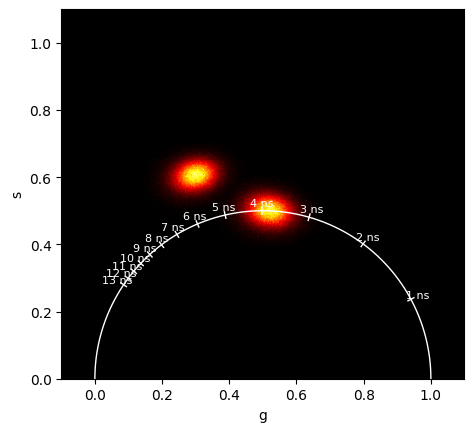

In [7]:
# Create alpha mask: transparent where H == min(H)
alpha = np.ones_like(H, dtype=float)
alpha[H == H.min()] = 0.0

fig, ax = plt.subplots()

im = ax.imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='hot',
    aspect='equal',
    alpha=alpha.T  # transpose alpha to match H.T
)
draw_unitary_circle(ax,sync_rate=TTResult_SyncRate)


H, xedges, yedges = np.histogram2d(g_smooth, s_smooth, bins=150)
alpha = np.ones_like(H, dtype=float)
alpha[H == H.min()] = 0.0
im = ax.imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='hot',
    aspect='equal',
    alpha=alpha.T  # transpose alpha to match H.T
)
ax.set_facecolor("black")
# plt.colorbar(im, ax=ax)
plt.show()


Fast & dirty calibration by shifting the decay

Orgiginal phasor value:  (0.29777028379167375+0.602187566044494j)
Phasor adjusted by decay shift:  (0.45084122614166117+0.49830536717998536j)
Phasor adjusted by multiplication:  (0.45083113583408513+0.49804446947086406j)


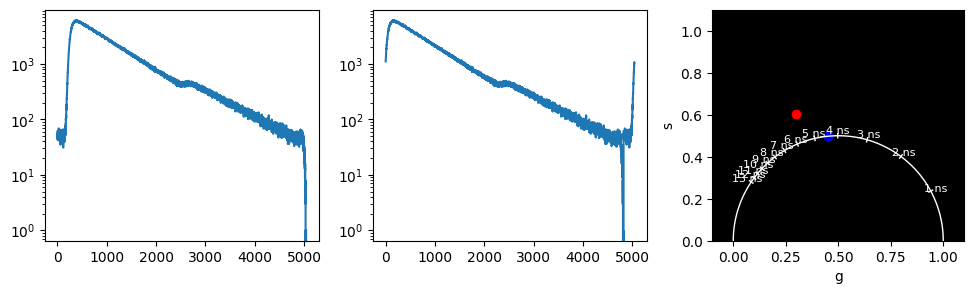

In [8]:
shift = 220

decay_shifted = shift_decay(decay.data,shift)

phasor = get_phasor_from_decay(decay=decay.data,tcspc_resolution=MeasDesc_Resolution,sync_rate=TTResult_SyncRate)
phasor_from_decay_shifted = get_phasor_from_decay(decay_shifted,tcspc_resolution=MeasDesc_Resolution,sync_rate=TTResult_SyncRate)
phasor_multiplied = np.exp(- 1j * shift * MeasDesc_Resolution * 2 * np.pi * TTResult_SyncRate) * phasor

print("Orgiginal phasor value: ", phasor)
print("Phasor adjusted by decay shift: ", phasor_from_decay_shifted)
print("Phasor adjusted by multiplication: ", phasor_multiplied)

# The phasor is influenced by the shift of the decay and IRF width. 
# Suggestion: find the decay shift using derivation of the decay

fig, ax = plt.subplots(1,3, figsize = (12,3))
ax[0].semilogy(decay.data)
ax[1].semilogy(decay_shifted)
ax[2].plot(phasor_from_decay.real,phasor_from_decay.imag,'ro')
ax[2].plot(phasor_from_decay_shifted.real,phasor_from_decay_shifted.imag,'go')
ax[2].plot(phasor_multiplied.real,phasor_multiplied.imag,'bo')
ax[2].set_aspect(1)
ax[2].set_xlim(0,1)
ax[2].set_ylim(0,1)
ax[2].set_facecolor('black')

draw_unitary_circle(ax=ax[2],sync_rate=TTResult_SyncRate)

plt.show()



361


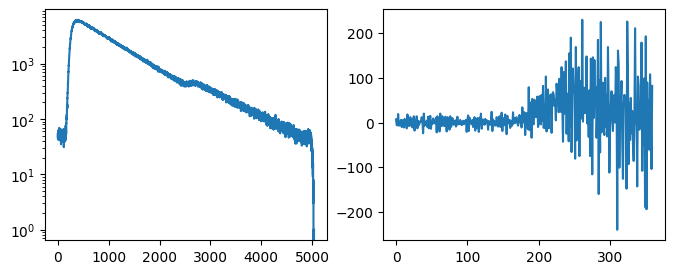

In [9]:
from scipy.ndimage import gaussian_filter1d

def triangular_smooth(x, window_size):
    weights = np.arange(1, window_size + 1)
    kernel = np.concatenate([weights, weights[::-1][1:]])
    kernel = kernel / kernel.sum()
    return np.convolve(x, kernel, mode='same')



# decay_smoothed = gaussian_filter1d(decay.data, sigma=40)
decay_smoothed = triangular_smooth(decay.data, 1)

decay_max = np.argmax(decay_smoothed,axis=0)

print(decay_max)

decay_derivative = np.diff(decay_smoothed[:decay_max])

fig, ax = plt.subplots(1,2, figsize = (8,3))
ax[0].semilogy(decay_smoothed)
ax[1].plot(decay_derivative)

Masking FLIM data based on selection from phasor

In [12]:
result = xr.open_dataset("test/data/MultiHarp150_2025-06-18_16-34-21.822_f1_ch1_accu4_px500.h5")
count = np.array(result.photon_count.transpose("frame","sequence","channel","line","pixel"), dtype=int)
lifetime = np.array(result.mean_photon_arrival_time.transpose("frame","sequence","channel","line","pixel"), dtype=float) * MeasDesc_Resolution * 1e9
g = np.array(result.phasor_g.transpose("frame","sequence","channel","line","pixel"), dtype=float)
s = np.array(result.phasor_s.transpose("frame","sequence","channel","line","pixel"), dtype=float)

count = count[0,0,0,:,:]

g = g[0,0,0,:,:]
s = s[0,0,0,:,:]

phasor = g + 1j * s



ValueError: did not find a match in any of xarray's currently installed IO backends ['scipy', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [13]:
phasor_calibrated = phasor * calibration_factor

phasor_calibrated_smoothed = smooth_phasor(phasor_calibrated,count)

valid = valid = np.isfinite(phasor) & (count > 0)


g_calibrated_smooth_valid = phasor_calibrated_smoothed[valid].real
s_calibrated_smooth_valid = phasor_calibrated_smoothed[valid].imag


H, xedges, yedges = np.histogram2d(g_calibrated_smooth_valid, s_calibrated_smooth_valid, bins=250)
# Create alpha mask: transparent where H == min(H)
alpha = np.ones_like(H, dtype=float)
alpha[H == H.min()] = 0.0

fig, ax = plt.subplots()

im = ax.imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='hot',
    aspect='equal',
    alpha=alpha.T  # transpose alpha to match H.T
)
draw_unitary_circle(ax,sync_rate=TTResult_SyncRate)

phasor_roi_1 = np.array([
    [0.9, 0.23],
    [1.0, 0.23],
    [1.05, 0.03],
    [0.98, 0.03]
])


x, y = phasor_roi_1.T
ax.plot(np.append(x, x[0]),          # close the loop
        np.append(y, y[0]),
        color='cyan', linewidth=2)

phasor_roi_2 = np.array([
    [0.75, 0.4],
    [0.85, 0.43],
    [0.98, 0.3],
    [0.85, 0.3]
])


x, y = phasor_roi_2.T
ax.plot(np.append(x, x[0]),          # close the loop
        np.append(y, y[0]),
        color='magenta', linewidth=2)


ax.set_facecolor("black")
# plt.colorbar(im, ax=ax)
plt.show()

IndexError: invalid index to scalar variable.

In [ ]:

from matplotlib.path import Path

roi_path_1 = Path(phasor_roi_1)
roi_path_2 = Path(phasor_roi_2)

# Stack g and s into pixel coordinate pairs
gs_coords = np.stack((phasor_calibrated_smoothed.real.ravel(), phasor_calibrated_smoothed.imag.ravel()), axis=-1)


# Check which coordinates fall inside the ROI
inside_mask_flat_1 = roi_path_1.contains_points(gs_coords)
inside_mask_flat_2 = roi_path_2.contains_points(gs_coords)
# Reshape to image shape
phasor_pixel_mask_1 = inside_mask_flat_1.reshape(count.shape)
phasor_pixel_mask_2 = inside_mask_flat_2.reshape(count.shape)
masked_img_1 = np.zeros_like(count)
masked_img_2 = np.zeros_like(count)
masked_img_1[phasor_pixel_mask_1] = count[phasor_pixel_mask_1]
masked_img_2[phasor_pixel_mask_2] = count[phasor_pixel_mask_2]
fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(masked_img_1,cmap='gray')
ax[1].imshow(masked_img_2,cmap='gray')

